Laboratorio 5: Incisos del 8 al 9

In [3]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer

In [4]:
filename= 'datos_limpios.csv'
data= pd.read_csv(filename)
df=pd.DataFrame(data)
df.head()

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0
2,1.0,1.0,30.23466,-97.73682,2,1.0,1.0,1.0,38.0,4,...,0,0,0,0,1,0,0,0,0,0
3,2.0,2.0,30.26098,-97.73072,3,2.0,2.0,2.0,145.0,15,...,0,0,0,0,1,0,0,0,0,0
4,1.0,1.0,30.23614,-97.73225,2,1.0,1.0,1.0,58.0,30,...,0,0,0,1,0,0,0,0,0,0


Tratamiento de datos NaN

In [5]:
df = df.fillna(df.median(numeric_only=True))

Separacion de datos en entrenamiento y prueba

In [6]:
categoria = []
#clasificacion de variable objetivo
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])

#Separacion de datos
X_train, X_test, y_train, y_test = train_test_split(df, categoria, test_size=0.2, random_state=0, stratify=categoria)

Escalamiento

In [7]:
columnas=X_train.columns
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [8]:
X_train=pd.DataFrame(X_train, columns=columnas)
X_test=pd.DataFrame(X_test, columns=columnas)


Eliminación de datos atípicos

In [9]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 3 * IQR
sup = Q3 + 3 * IQR

Problema 8: Validación cruzada

In [10]:
#La siguiente hace validación cruzada de un modelo ne Naive Bayes
def NBCVmetric(X, y, cv=5, scoring="accuracy"):
    
    modeloNB = GaussianNB(var_smoothing=1e-20)
    
    kfold = StratifiedKFold(n_splits=cv,shuffle=True,random_state=0)
    
    scores = cross_val_score(modeloNB,X,y,cv=kfold,scoring=scoring)
    
    return {
        "scores": scores,
        "mean": np.mean(scores),
        "std": np.std(scores)
    }

In [11]:
pd.DataFrame(NBCVmetric(X_train, y_train, cv=2))

,scores,mean,std
0,0.389259,0.429019,0.03976
1,0.468779,0.429019,0.03976


Se observa que el valor de la Exactitud (accuracy) es mayor en ambas iteraciones que el valor del modelo del inciso anterior, ya que este valor en el inciso anterior era de $0.38885112168592795$. Es de esta manera, este es un indicio de que el modelo es ligeramente mejor. 

<Figure size 800x600 with 0 Axes>

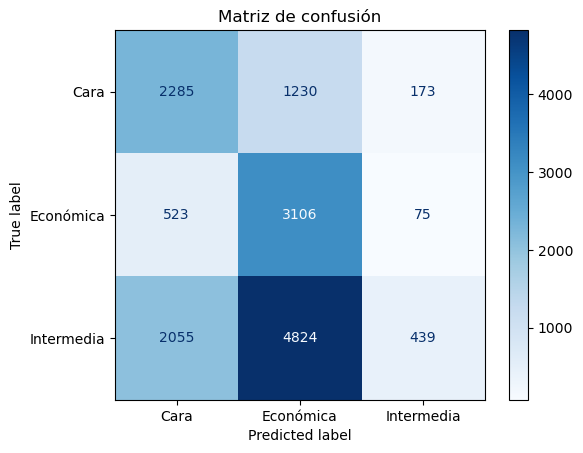

In [12]:
modeloNB=GaussianNB(var_smoothing=1e-20)
modeloNB.fit(X_train, y_train)
kfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
y_pred=cross_val_predict(modeloNB,X_test, y_test,cv=kfold)

class_names = [str(c) for c in modeloNB.classes_]
cm = confusion_matrix(y_test, y_pred, labels=modeloNB.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()

Se observa de la matriz de confusión que este modelo tiene mayor número de errores en cada parte de la matriz que el del inciso anterior. De manera que aunque es un buen modelo, es más propoenso a fallar que el del inciso anterior. 

Inciso 9: Ajuste de Modelo de Naive Bayes para Clasificación

La siguiente función busca los mejores hiperparámetros para el modelo de Naive Bayes y devuelve aquellos que hay que cambiar para hacer que el valor de score incremente.

In [13]:
def NB_grid(X, y):
    
    NBcv = GaussianNB()
    param_grid = {
        "var_smoothing": np.logspace(-12, -6, 20)
    }
    
    grid = GridSearchCV(
        NBcv,
        param_grid,
        cv=5,
        scoring="accuracy"
    )
    
    grid.fit(X, y)
    
    return grid

In [14]:
grid=NB_grid(X_train, y_train)

In [15]:
print("Mejor parámetro:", grid.best_params_)
print("Mejor score:", grid.best_score_)

Mejor parámetro: {'var_smoothing': np.float64(1e-06)}
Mejor score: 0.47782931988357447


Se procede a hacer los correspondientes cambios al modelo y evaluar si este ha mejorado o no:

<Figure size 800x600 with 0 Axes>

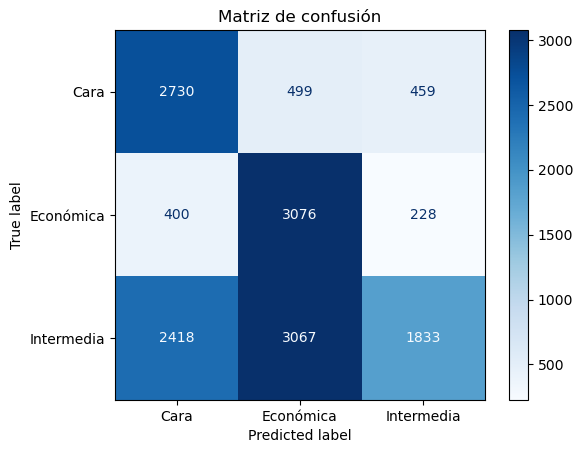

In [16]:
modeloNB2=GaussianNB(var_smoothing=1e-06)
modeloNB2.fit(X_train, y_train)
kfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
y_pred2=cross_val_predict(modeloNB2,X_test, y_test,cv=kfold)

class_names = [str(c) for c in modeloNB2.classes_]
cm = confusion_matrix(y_test, y_pred2, labels=modeloNB.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()

In [17]:
kfold = StratifiedKFold(n_splits=2,shuffle=True,random_state=0)
scores = cross_val_score(modeloNB,X_test,y_test,cv=kfold,scoring="accuracy")
scores=np.mean(scores)
print("Mean Accuracy: ",scores)

Mean Accuracy:  0.3892590074779062


Es posible observar que al hacer el proceso de ajuste de los hiperparámetros, el modelo no mejoró. Esto se puede ver en el valor medio de accuracy(exactitud), así como el hecho que en general, los errores de la matriz de confusión no se redujeron.

Inciso 9: Ajuste del modelo de Naive Bayes para Regresión:

Se procede a hacer uso del método empleado en el programa de incisos 1 al 3 para este objetivo

In [25]:
df1=pd.DataFrame(data)
X = df1.drop(columns=['price'])
y = df1['price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(df1, y, test_size=0.25, random_state=42)
y_train2=np.array(y_train2)
y_test2=np.array(y_test2)

In [26]:
# Reemplzar valores nan
imputer = SimpleImputer(strategy="mean")
X_train_imp = imputer.fit_transform(X_train2)   # fit solo en train
X_test_imp  = imputer.transform(X_test2)        # transform en test (sin re-fit)
 
#    Naive Bayes es un clasificador; se mapea
#    cada precio a un intervalo y luego se
#    usa el centro del bin como predicción.
N_BINS = 50
bins = np.linspace(y.min(), y.max() + 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
 
y_train_binned = np.clip(np.digitize(y_train2, bins) - 1, 0, N_BINS - 1)
 
# Entrenamiento del modelo
model = GaussianNB()
model.fit(X_train_imp, y_train_binned)
 
#    El modelo predice el bin; se convierte
#    al centro del intervalo como valor numérico.
y_pred_bins = model.predict(X_test_imp)
y_pred = bin_centers[y_pred_bins]
 

In [29]:
#La siguiente función ajusta los correspondientes hiperparámetros
def NB_regression_tuning(X_train, X_test, y_train, y_test, bins_list=[10, 20, 50, 100], smoothing_list=np.logspace(-12, -6, 5)):
    
    resultados = []
    
    for N_BINS in bins_list:
        

        bins = np.linspace(y_train.min(), y_train.max()+1, N_BINS+1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        y_train_binned = np.clip(
            np.digitize(y_train, bins) - 1,
            0,
            N_BINS-1
        )
        

        imputer = SimpleImputer(strategy="mean")
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp = imputer.transform(X_test)
        
        for smoothing in smoothing_list:
            

            model = GaussianNB(var_smoothing=smoothing)
            model.fit(X_train_imp, y_train_binned)
          
            y_pred_bins = model.predict(X_test_imp)
            y_pred = bin_centers[y_pred_bins]
            
           
            mse    = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            resultados.append({
                "bins": N_BINS,
                "var_smoothing": smoothing,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2
            })
    
    return resultados

In [30]:
res = NB_regression_tuning(X_train2, X_test2, y_train2, y_test2)
df2 = pd.DataFrame(res)

df2.sort_values("RMSE").head()

,bins,var_smoothing,MSE,RMSE,R2
15,100,1.000000e-12,9.534351e+05,976.439999,0.946178
16,100,3.162278e-11,1.035922e+06,1017.802478,0.941522
17,100,1.000000e-09,1.092954e+06,1045.444352,0.938302
10,50,1.000000e-12,1.574542e+06,1254.807426,0.911116
11,50,3.162278e-11,1.583428e+06,1258.343159,0.910615


Se observa, respecto al modelo original de regresión con Naive Bayes, que el valor de MSE es menor que el del primer modelo ($MSE=33,315,537.1715$) para todos los valores de var_smoothing considerados anteriormente ($1e-12,3.162278e-11,1e-9$) para bins de 100 y 50.

Para valores de RMSE, el valor de los nuevos modelos es menor que el del modelo original ($RMSE=5,771.9613$), para todos los valores de var_smoothing considerados anteriormente ($1e-12,3.162278e-11,1e-9$) para bins de 100 y 50.

Para valores de $R^2$ se tiene que para todos los valores de var_smoothing considerados anteriormente ($1e-12,3.162278e-11,1e-9$) para bins de 100 y 50, el valor de los nuevos valores es ligeramente mayor que el del modelo original ($R^2=-0.8807$) al comparar los valores absolutos.

De esta manera resulta que en los nuevos modelos son generalmente mejores al original, para todos los valores de var_smoothing considerados anteriormente ($1e-12,3.162278e-11,1e-9$) para bins de 100 y 50.


Problema 10: Comparación con el modelo de Random Forest del Laboratorio 4

Se tiene que el modelo de Random Forest implementado en el último inciso del laboratorio 4, resultó ser superior al modelo implementado por Naive Bayes. Esto por lo siguiente:

1. Accuracy Random Forest(0.851393...) > Accuracy de Naive Bayes (0.47782931988357447), lo que significa que el Random Forest es predice los resultados con mayor exactitud.

2. La matriz de confusión del modelo de Random Forest presenta menor cantidad de errores, de cualquier tipo, que aquella hecha por Naive Bayes.